In [111]:
from leitor_csv import ler_csvs_inbe
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
df = ler_csvs_inbe()

ArrowMemoryError: realloc of size 134217728 failed

In [ ]:
df.head()

,latitude,longitude,data_pas,satelite,pais,estado,municipio,bioma,numero_dias_sem_chuva,precipitacao,risco_fogo,id_area_industrial,frp
0,-17.55708,-57.20554,2023-01-02 02:08:00,TERRA_M-M,Brasil,MATO GROSSO,POCONÃ,Pantanal,0.0,0.20,0.01,0,4.5
1,-17.55838,-57.21490,2023-01-02 02:08:00,TERRA_M-M,Brasil,MATO GROSSO,POCONÃ,Pantanal,0.0,0.15,0.01,0,14.5
2,-17.62477,-57.29403,2023-01-02 02:08:00,TERRA_M-M,Brasil,MATO GROSSO,POCONÃ,Pantanal,0.0,0.00,0.02,0,8.8
3,-17.62712,-57.17881,2023-01-02 02:08:00,TERRA_M-M,Brasil,MATO GROSSO,POCONÃ,Pantanal,0.0,0.10,0.02,0,6.7
4,-19.44473,-53.99815,2023-01-02 02:08:00,TERRA_M-M,Brasil,MATO GROSSO DO SUL,CAMAPUÃ,Cerrado,0.0,15.10,0.01,0,6.1


In [ ]:
df.dtypes

latitude                 float64
longitude                float64
data_pas                     str
satelite                     str
pais                         str
estado                       str
municipio                    str
bioma                        str
numero_dias_sem_chuva    float64
precipitacao             float64
risco_fogo               float64
id_area_industrial         int64
frp                      float64
dtype: object

In [ ]:
df.describe()

,latitude,longitude,numero_dias_sem_chuva,precipitacao,risco_fogo,id_area_industrial,frp
count,1.628756e+07,1.628756e+07,1.621654e+07,1.621654e+07,1.621654e+07,16287563.0,1.576894e+07
mean,-9.727313e+00,-5.189594e+01,1.723138e+01,6.286326e-01,-8.654785e+00,0.0,3.844735e+01
std,5.824589e+00,7.248283e+00,1.083397e+02,3.220243e+00,9.669894e+01,0.0,7.128829e+01
min,-3.373760e+01,-7.386338e+01,-9.990000e+02,0.000000e+00,-9.990000e+02,0.0,-3.800000e+00
25%,-1.308679e+01,-5.713660e+01,4.000000e+00,0.000000e+00,6.200000e-01,0.0,3.800000e+00
50%,-9.002310e+00,-5.128070e+01,1.100000e+01,0.000000e+00,1.000000e+00,0.0,1.000000e+01
75%,-6.059900e+00,-4.597600e+01,3.600000e+01,0.000000e+00,1.000000e+00,0.0,5.640000e+01
max,5.217610e+00,-3.479613e+01,1.200000e+02,2.529800e+02,1.000000e+00,0.0,1.231130e+04


In [ ]:
df['data'] = pd.to_datetime(df['data_pas'], errors='coerce')
df['mes'] = df['data'].dt.month
df['ano'] = df['data'].dt.year
df['semana'] = df['data'].dt.isocalendar().week

In [ ]:
df['bioma'].unique()

<ArrowStringArray>
['Pantanal', 'Cerrado', 'Mata AtlÃ¢ntica', 'Caatinga', 'AmazÃ´nia', 'Pampa',
 nan]
Length: 7, dtype: str

In [ ]:
df['id_area_industrial'] =df['id_area_industrial'].apply(lambda x: 1 if x > 0 else 0)
df['numero_dias_sem_chuva'] = df['numero_dias_sem_chuva'].apply(lambda x: np.nan if x < 0 else x)
df['risco_fogo'] = df['risco_fogo'].apply(lambda x: np.nan if x < 0 else x)

df['numero_dias_sem_chuva'] = df['numero_dias_sem_chuva'].fillna(df['numero_dias_sem_chuva'].median())
df['risco_fogo'] = df['risco_fogo'].fillna(df['risco_fogo'].median())

mapa_biomas = {'Mata AtlÃ¢ntica' : 'Mata Atlântica', 'Cerrado' : 'Cerrado', 'AmazÃ´nia' : 'Amazônia', 'Pampa' : 'Pampa', 'Pantanal' : 'Pantanal', 'Caatinga' : 'Caatinga'}

df['bioma'] = df['bioma'].map(mapa_biomas)
df = df.rename(columns={'id_area_industrial': 'area_industrial'})
df = df.drop(columns=['data_pas'])


In [ ]:
df.head()

,latitude,longitude,satelite,pais,estado,municipio,bioma,numero_dias_sem_chuva,precipitacao,risco_fogo,area_industrial,frp,data,mes,ano,semana
0,-17.55708,-57.20554,TERRA_M-M,Brasil,MATO GROSSO,POCONÃ,Pantanal,0.0,0.20,0.01,0,4.5,2023-01-02 02:08:00,1,2023,1
1,-17.55838,-57.21490,TERRA_M-M,Brasil,MATO GROSSO,POCONÃ,Pantanal,0.0,0.15,0.01,0,14.5,2023-01-02 02:08:00,1,2023,1
2,-17.62477,-57.29403,TERRA_M-M,Brasil,MATO GROSSO,POCONÃ,Pantanal,0.0,0.00,0.02,0,8.8,2023-01-02 02:08:00,1,2023,1
3,-17.62712,-57.17881,TERRA_M-M,Brasil,MATO GROSSO,POCONÃ,Pantanal,0.0,0.10,0.02,0,6.7,2023-01-02 02:08:00,1,2023,1
4,-19.44473,-53.99815,TERRA_M-M,Brasil,MATO GROSSO DO SUL,CAMAPUÃ,Cerrado,0.0,15.10,0.01,0,6.1,2023-01-02 02:08:00,1,2023,1


In [ ]:
satelites = df['satelite'].unique()
biomas_maiores_focos = df['bioma'].value_counts()
meses_maiores_focos = df['mes'].value_counts()

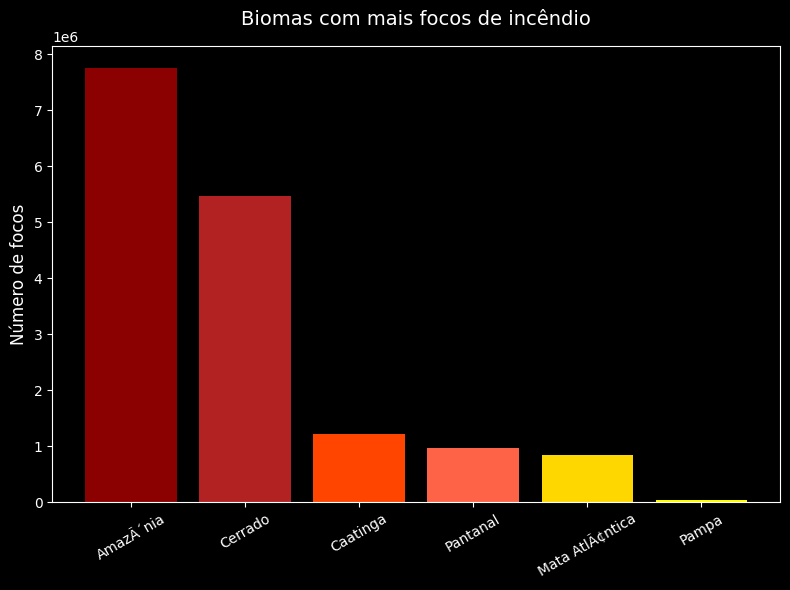

In [ ]:

plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(8,6))

# Paleta neon personalizada
colors = [
    '#8B0000',  # vermelho escuro
    '#B22222',  # vermelho tijolo
    '#FF4500',  # laranja forte
    '#FF6347',  # vermelho tomate
    '#FFD700',  # amarelo ouro
    '#FFFF00'   # amarelo puro
]

ax.bar(
    biomas_maiores_focos.index,
    biomas_maiores_focos.values,
    color=colors
)

ax.set_title("Biomas com mais focos de incêndio", fontsize=14, color="white", pad=15)
ax.set_ylabel("Número de focos", fontsize=12, color="white")

# Tirar grid
ax.grid(False)

# Ajustar ticks
ax.tick_params(axis="x", colors="white", rotation=30)
ax.tick_params(axis="y", colors="white")

plt.tight_layout()
plt.show()


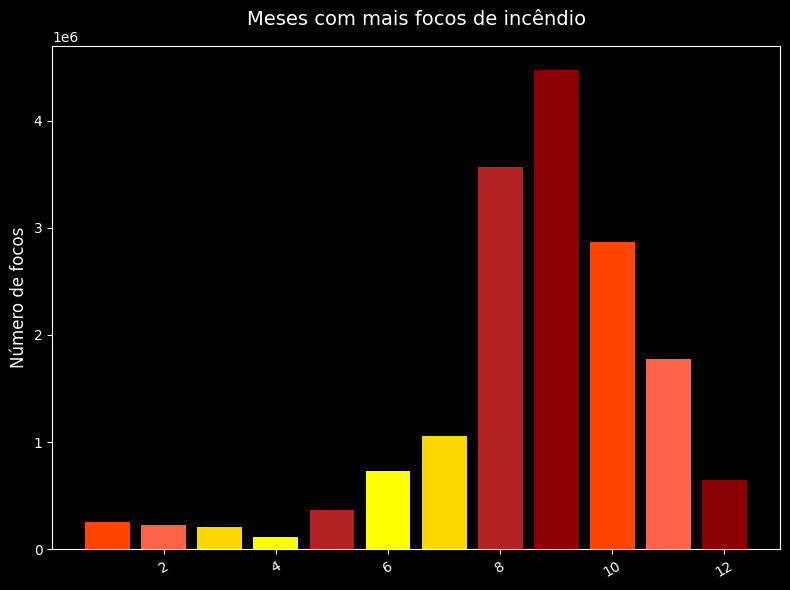

In [ ]:

plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(8,6))

# Paleta neon personalizada
colors = [
    '#8B0000',  # vermelho escuro
    '#B22222',  # vermelho tijolo
    '#FF4500',  # laranja forte
    '#FF6347',  # vermelho tomate
    '#FFD700',  # amarelo ouro
    '#FFFF00'   # amarelo puro
]

ax.bar(
    meses_maiores_focos.index,
    meses_maiores_focos.values,
    color=colors
)

ax.set_title("Meses com mais focos de incêndio", fontsize=14, color="white", pad=15)
ax.set_ylabel("Número de focos", fontsize=12, color="white")

# Tirar grid
ax.grid(False)

# Ajustar ticks
ax.tick_params(axis="x", colors="white", rotation=30)
ax.tick_params(axis="y", colors="white")

plt.tight_layout()
plt.show()
